In [8]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import pickle
from sbi.analysis import pairplot
import yaml
import scipy

# Import local packages
from examples.unif_norm import (
    prior_pdf,
    get_approximate_posterior_density,
    true_posterior_pdf,
    approximate_posterior_quantiles_against_x,
    plot_approximate_posterior_quantiles_against_x,
    plot_approximate_posterior_quantiles_diff_against_x,
    plot_leakage_factors
)
from sbc.sbc_tools import plot_sbc_all
algorithm_names = ["npe_c", "tsnpe", "nle_mcmc", "nle_vi", "nre"]
algorithm_names_to_nice = {"npe_c": "SNPE-C",
                                  "tsnpe": "TSNPE",
                                  "nle_mcmc": "SNLE-MCMC",
                                  "nle_vi": "SNLE-VI",
                                  "nre": "SNRE-B"}
algorithm_KLs_squared_norms_ID = {"npe_c": [2,1,0,3,5,4],
                                  "tsnpe": [1,2,0,7,np.nan,np.nan],
                                  "nle_mcmc": [2,1,0,5,6,7],
                                  "nle_vi": [2,1,0,6,8,9],
                                  "nre": [3,2,1,6,7,8]} # Maps each algo to the experiment IDs of the d=3,10,25,50,100 experiments, respectively.
d_list = [3,10,25,50,75,100]

In [13]:
squared_norms_dicts = {algorithm_name : [] for algorithm_name in algorithm_names}
KLs_squared_norms_configs = {algorithm_name : [] for algorithm_name in algorithm_names}

for algorithm_name in algorithm_names:
    KLs_squared_norms_IDs = algorithm_KLs_squared_norms_ID[algorithm_name] # List of experiment IDs
    for i, experiment_ID in enumerate(KLs_squared_norms_IDs):
        if not np.isnan(experiment_ID): # Ignore unfinished experiments
            d = d_list[i]
            results_path = "/Users/Lieve/Documents/Masters Project/SBC-SBI/results/toy_examples/unif_norm" + f"/{algorithm_name}/"
            config_path = results_path + f"KLs_squared_norms{experiment_ID}.yaml"
            squared_norms_path = results_path + f"/KLs_squared_norms{experiment_ID}_squared_norms_dict.npz"

            # Load config
            with open(config_path, "r") as f:
                KLs_squared_norms_config = yaml.safe_load(f)
            KLs_squared_norms_configs[algorithm_name].append(KLs_squared_norms_config)

            # Load squared norms
            squared_norms_dict_ = dict(np.load(squared_norms_path))
            squared_norms_dicts[algorithm_name].append(squared_norms_dict_["round_7"])

In [14]:
def plot_training_parameter_squared_norms(squared_norms_list, d, alpha=0.1, title=None, ax=None, include_legend=True):
    user_defined_ax = ax is not None
    if not user_defined_ax:
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.set_xlabel(r"Dimension $d$")
        ax.set_ylabel(r"$||\theta||^2_2$ where $\theta \sim \tilde{\pi}_r(\theta|x)$")
    if title is None:
        pass
        #ax.set_title(f"Mean and quantiles of $||\\theta||^2_2$ (±2 SE) from posterior approximation at each round")
    else:
        ax.set_title(title)
    ax.set_prop_cycle(None)

    mean_means = []
    mean_lqs = []
    mean_uqs = []

    se_means = []
    se_lqs = []
    se_uqs = []

    ds = []
    for i, squared_norms in enumerate(squared_norms_list): # shape: (num_repetitions, num_simulations_per_round)
        d = d_list[i]
        ds.append(d)
        
        # Per-repetition statistics
        means = np.mean(squared_norms, axis=1)
        lqs = np.quantile(squared_norms, alpha / 2, axis=1)
        uqs = np.quantile(squared_norms, 1 - alpha / 2, axis=1)

        R = len(means)

        # Averages across repetitions
        mean_means.append(np.mean(means))
        mean_lqs.append(np.mean(lqs))
        mean_uqs.append(np.mean(uqs))

        # Standard errors across repetitions
        se_means.append(np.std(means, ddof=1) / np.sqrt(R))
        se_lqs.append(np.std(lqs, ddof=1) / np.sqrt(R))
        se_uqs.append(np.std(uqs, ddof=1) / np.sqrt(R))

    ds = np.array(ds)

    mean_means = np.array(mean_means)
    mean_lqs = np.array(mean_lqs)
    mean_uqs = np.array(mean_uqs)

    se_means = np.array(se_means)
    se_lqs = np.array(se_lqs)
    se_uqs = np.array(se_uqs)

    # True values
    true_lqs = np.array([scipy.stats.chi2.ppf(alpha / 2, df=d) for d in ds])
    true_uqs = np.array([scipy.stats.chi2.ppf(1 - alpha / 2, df=d) for d in ds])

    # Plot mean with ±1 SE
    ax.errorbar(
        ds,
        mean_means,
        yerr=2 * se_means,
        fmt="o",
        capsize=4,
        markersize=4,
        label="Approximate mean ± 2 SE",
    )

    # Plot lower quantile with ±1 SE
    ax.errorbar(
        ds,
        mean_lqs,
        yerr=2 * se_lqs,
        fmt="o",
        capsize=4,
        markersize=4,
        label=f"Approximate {100*alpha/2:.1f}% quantile ± 2 SE",
    )

    # Plot upper quantile with ±1 SE
    ax.errorbar(
        ds,
        mean_uqs,
        yerr=2 * se_uqs,
        fmt="o",
        capsize=4,
        markersize=4,
        label=f"Approximate {100*(1-alpha/2):.1f}% quantile ± 2 SE",
    )

    ax.plot(ds, ds, color="k", linestyle="--", label="True mean of " + r"$||\theta||_2^2$")
    
    ax.fill_between(ds, true_lqs, true_uqs, alpha=0.2, color="gray",
                    label=f"True {100*alpha/2:.1f}% and {100*(1-alpha/2):.1f}% quantile of " + r"$||\theta||_2^2$")

    ax.vlines(
        ds,
        mean_lqs,
        mean_uqs,
        colors="gray",
        linewidth=1,
        alpha=0.7,
        zorder=0,
    )
    ax.set_yscale("log")

    #ax.set_xticks(ds)
    if include_legend:
        ax.legend(fontsize=9)
    return ax

<Axes: xlabel='Dimension $d$', ylabel='$||\\theta||^2_2$ where $\\theta \\sim \\tilde{\\pi}_r(\\theta|x)$'>

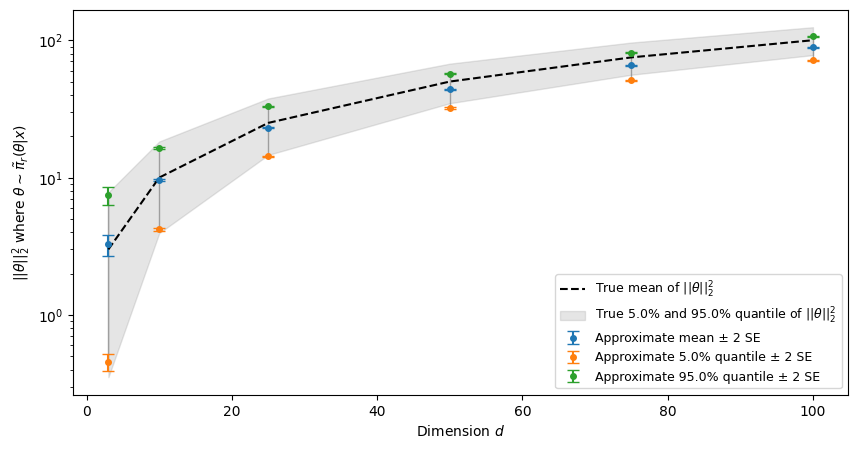

In [15]:
squared_norms_list = squared_norms_dicts["nle_vi"]
plot_training_parameter_squared_norms(squared_norms_list, d, alpha=0.1, title=None, ax=None, include_legend=True)

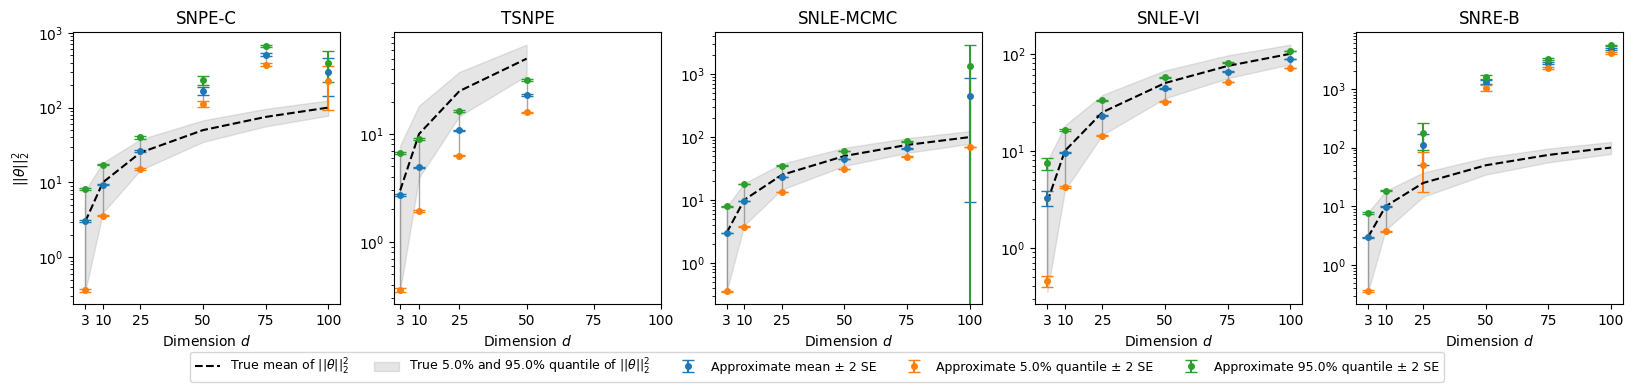

In [16]:
fig, ax = plt.subplots(figsize=(20, 4), ncols=5)
for j in range(5):
    algorithm_name = algorithm_names[j]
    squared_norms_list = squared_norms_dicts[algorithm_name]
    title = algorithm_names_to_nice[algorithm_name]
    include_legend = False
    plot_training_parameter_squared_norms(squared_norms_list, d=d, title=title, ax=ax[j], include_legend=False)
    ax[j].set_xlabel(r"Dimension $d$")
    ax[j].set_xticks(d_list)
    if j == 0:
        ax[j].set_ylabel(r"$||\theta||_2^2$")
# Add one legend for all subplots
handles, labels = ax[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=5, fontsize=9)
#plt.tight_layout()
plt.subplots_adjust(bottom=0.2)  # top=0.75 leaves room for legend
plt.show()

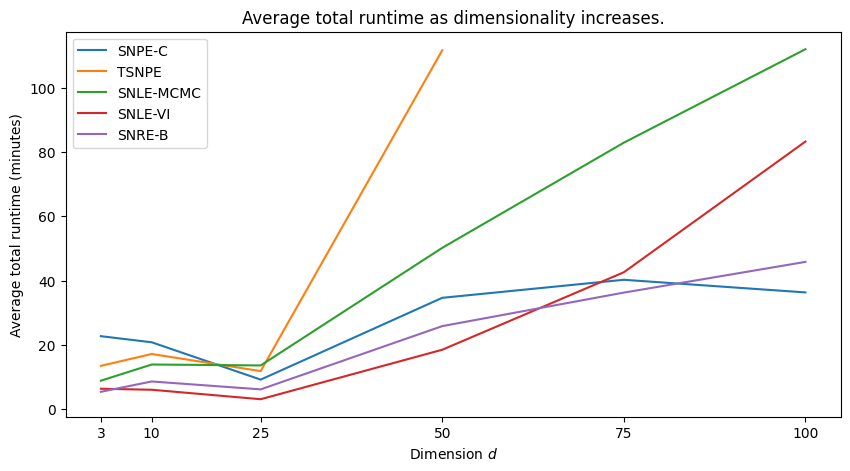

In [17]:
fig, ax = plt.subplots(figsize=(10,5))
for algorithm_name in algorithm_names:
    ds = []
    runtimes = []
    for i, config in enumerate(KLs_squared_norms_configs[algorithm_name]):
        d = d_list[i]
        ds.append(d)
        runtimes.append(sum(list(config["avg_training_times"].values())) + sum(list(config["avg_simulation_times"].values())))
    ax.plot(ds, [r / 60 for r in runtimes], label=f"{algorithm_names_to_nice[algorithm_name]}")

ax.set_xlabel(r"Dimension $d$")
ax.set_ylabel("Average total runtime (minutes)")
ax.set_xticks(ds)
ax.set_title("Average total runtime as dimensionality increases.")
ax.legend()
plt.show()

In [18]:
# Analyzing the failed d = 100 SNLE-MCMC run
l = []
for i in range(10):
    l.append(round(max(squared_norms_dicts["nle_mcmc"][-1][i,:]), 1))
l

[133.8, 141.8, 155.1, 147.1, 7849.9, 164.5, 153.6, 6301.1, 142.1, 7812.9]